# English–Amharic NMT Preprocessing Analysis

This notebook analyzes and verifies the output of the centralized preprocessing pipeline:

```text
src/nmt/data/clean.py


##  Imports

In [1]:
from pathlib import Path
import sys
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

print("Imports completed.")

Imports completed.


### Locate project root and files

In [2]:
PROJECT_ROOT = Path.cwd()

# Support execution from either the project root or notebooks/ directory.
if not (PROJECT_ROOT / "data").exists() and (PROJECT_ROOT.parent / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

RAW_FILE = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "mt560_amharic_english"
    / "train.parquet"
)

CLEAN_FILE = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "mt560_amharic_english"
    / "train_clean.parquet"
)

CLEAN_EN_FILE = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "mt560_amharic_english"
    / "train_clean.en"
)

CLEAN_AM_FILE = (
    PROJECT_ROOT
    / "data"
    / "interim"
    / "mt560_amharic_english"
    / "train_clean.am"
)

print("Project root:", PROJECT_ROOT)
print("Raw file    :", RAW_FILE)
print("Clean file  :", CLEAN_FILE)

if not RAW_FILE.exists():
    raise FileNotFoundError(f"Raw dataset not found: {RAW_FILE}")

if not CLEAN_FILE.exists():
    raise FileNotFoundError(
        f"Cleaned dataset not found: {CLEAN_FILE}\n"
        "Run: python src/nmt/data/clean.py"
    )

print("\nAll required dataset files were found.")

Project root: c:\Users\olibe\Desktop\neural-machine-translation
Raw file    : c:\Users\olibe\Desktop\neural-machine-translation\data\raw\mt560_amharic_english\train.parquet
Clean file  : c:\Users\olibe\Desktop\neural-machine-translation\data\interim\mt560_amharic_english\train_clean.parquet

All required dataset files were found.


## 1. Load Raw and Cleaned Datasets

In [3]:
raw_df = pd.read_parquet(RAW_FILE)
clean_df = pd.read_parquet(CLEAN_FILE)

print(f"Raw dataset rows    : {len(raw_df):,}")
print(f"Cleaned dataset rows: {len(clean_df):,}")

print("\nRaw columns:")
print(raw_df.columns.tolist())

print("\nCleaned columns:")
print(clean_df.columns.tolist())

Raw dataset rows    : 669,145
Cleaned dataset rows: 662,491

Raw columns:
['eng', 'amh']

Cleaned columns:
['eng', 'amh']


In [4]:
print("Raw dataset sample:")
display(raw_df.head())

print("\nCleaned dataset sample:")
display(clean_df.head())

Raw dataset sample:


,eng,amh
0,"Much of that wisdom concerned Jehovah 's creation : "" [ Solomon ] would speak about the trees , from the cedar that is in Lebanon to the hyssop that is coming forth on the wall ; and he would spea...",[ ሰሎሞን ] ስለ ዛፍም ከሊባኖስ ዝግባ ጀምሮ በቅጥር ግንብ ላይ እስከሚበቅለው እስከ ሂሶጵ ድረስ ይናገር ነበር ፤ ደግሞም ስለ አውሬዎችና ስለ ወፎች ስለ ተንቀሳቃሾችና ስለ ዓሣዎች ይናገር ነበር ።
1,"A "" Necklace to Your Throat """,ለአንገትህም ድሪ ይሆንልሃልና
2,"that He may forgive you some of your sins and respite you until a specified time . Indeed when Allah ' s [ appointed ] time comes , it cannot be deferred , if you know . '",ለእናንተ ከኀጢኣቶቻችሁ ይምራልና ፡ ፡ ወደተወሰነው ጊዜም ያቆያችኋል ፡ ፡ የአላህ ( የወሰነው ) ጊዜ በመጣ ወቅት አይቆይም ፡ ፡ የምታውቁት ብትኾኑ ኖሮ ( በታዘዛችሁ ነበር ) ፡ ፡
3,Let all malicious bitterness and anger and wrath and screaming and abusive speech be taken away from you .,መራርነትና ንዴት ቊጣም ጩኸትም መሳደብም ሁሉ ከክፋት ሁሉ ጋር ከእናንተ ዘንድ ይወገድ ።
4,"See the box entitled "" Why Does the Bible Describe God in Human Terms ? "" [ Box on page 7 ]",መጽሐፍ ቅዱስ አምላክን ሰብዓዊ አካል እንዳለው አድርጐ የሚገልጸው ለምንድን ነው ?



Cleaned dataset sample:


,eng,amh
0,"Much of that wisdom concerned Jehovah 's creation : "" [ Solomon ] would speak about the trees , from the cedar that is in Lebanon to the hyssop that is coming forth on the wall ; and he would spea...",[ ሰሎሞን ] ስለ ዛፍም ከሊባኖስ ዝግባ ጀምሮ በቅጥር ግንብ ላይ እስከሚበቅለው እስከ ሂሶጵ ድረስ ይናገር ነበር ፤ ደግሞም ስለ አውሬዎችና ስለ ወፎች ስለ ተንቀሳቃሾችና ስለ ዓሣዎች ይናገር ነበር ።
1,"A "" Necklace to Your Throat """,ለአንገትህም ድሪ ይሆንልሃልና
2,"that He may forgive you some of your sins and respite you until a specified time . Indeed when Allah ' s [ appointed ] time comes , it cannot be deferred , if you know . '",ለእናንተ ከኀጢኣቶቻችሁ ይምራልና ፡ ፡ ወደተወሰነው ጊዜም ያቆያችኋል ፡ ፡ የአላህ ( የወሰነው ) ጊዜ በመጣ ወቅት አይቆይም ፡ ፡ የምታውቁት ብትኾኑ ኖሮ ( በታዘዛችሁ ነበር ) ፡ ፡
3,Let all malicious bitterness and anger and wrath and screaming and abusive speech be taken away from you .,መራርነትና ንዴት ቊጣም ጩኸትም መሳደብም ሁሉ ከክፋት ሁሉ ጋር ከእናንተ ዘንድ ይወገድ ።
4,"See the box entitled "" Why Does the Bible Describe God in Human Terms ? "" [ Box on page 7 ]",መጽሐፍ ቅዱስ አምላክን ሰብዓዊ አካል እንዳለው አድርጐ የሚገልጸው ለምንድን ነው ?


### Validate required columns

In [5]:
required_columns = {"eng", "amh"}

if not required_columns.issubset(raw_df.columns):
    raise ValueError(
        f"Raw dataset is missing columns: {required_columns - set(raw_df.columns)}"
    )

if not required_columns.issubset(clean_df.columns):
    raise ValueError(
        f"Cleaned dataset is missing columns: {required_columns - set(clean_df.columns)}"
    )

print("Both datasets contain the required columns:", sorted(required_columns))

Both datasets contain the required columns: ['amh', 'eng']


## 2. Dataset Size Comparison

### Compare row counts

In [6]:
raw_count = len(raw_df)
clean_count = len(clean_df)

removed_count = raw_count - clean_count
retention_percentage = clean_count / raw_count * 100
removal_percentage = removed_count / raw_count * 100

size_comparison = pd.DataFrame({
    "Dataset": ["Raw dataset", "Cleaned dataset"],
    "Number of pairs": [raw_count, clean_count],
})

display(size_comparison)

print(f"Removed pairs : {removed_count:,}")
print(f"Retention     : {retention_percentage:.2f}%")
print(f"Removal rate  : {removal_percentage:.2f}%")

,Dataset,Number of pairs
0,Raw dataset,669145
1,Cleaned dataset,662491


Removed pairs : 6,654
Retention     : 99.01%
Removal rate  : 0.99%


### Dataset size chart

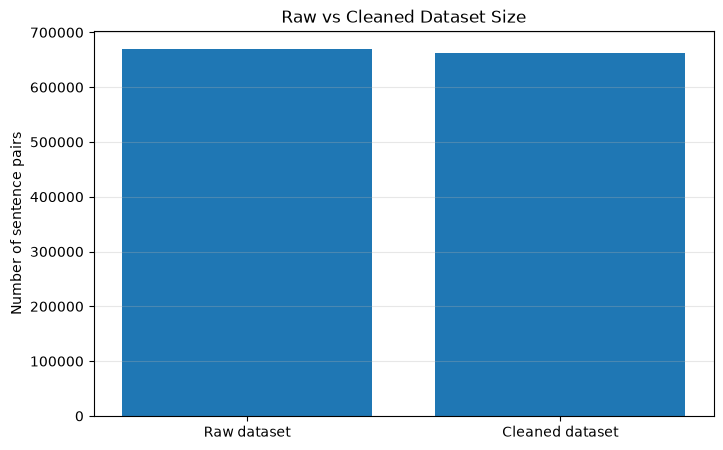

In [7]:
plt.figure(figsize=(8, 5))

plt.bar(
    ["Raw dataset", "Cleaned dataset"],
    [raw_count, clean_count]
)

plt.title("Raw vs Cleaned Dataset Size")
plt.ylabel("Number of sentence pairs")
plt.grid(axis="y", alpha=0.3)

plt.show()

## 3. Reproduce the Centralized Cleaning Report

The cleaning logic is imported from:

```text
src/nmt/data/clean.py

###  Import `clean_corpus`


In [9]:
pip install torch --index-url https://download.pytorch.org/whl/cpu


Looking in indexes: https://download.pytorch.org/whl/cpu
   ---------------------------------------- 0.0/125.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/125.9 MB 2.6 MB/s eta 0:00:49
   ---------------------------------------- 0.5/125.9 MB 2.6 MB/s eta 0:00:49
   ---------------------------------------- 0.8/125.9 MB 1.1 MB/s eta 0:01:59
   ---------------------------------------- 1.0/125.9 MB 988.9 kB/s eta 0:02:07
   ---------------------------------------- 1.0/125.9 MB 988.9 kB/s eta 0:02:07
   ---------------------------------------- 1.3/125.9 MB 948.8 kB/s eta 0:02:12
   ---------------------------------------- 1.6/125.9 MB 925.6 kB/s eta 0:02:15
   ---------------------------------------- 1.6/125.9 MB 925.6 kB/s eta 0:02:15
    --------------------------------------- 1.8/125.9 MB 908.5 kB/s eta 0:02:17
    --------------------------------------- 2.1/125.9 MB 900.5 kB/s eta 0:02:18
    --------------------------------------- 2.1/125.9 MB 900.5 kB/s eta 0:02:1

In [11]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent  # or wherever your root is
sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from nmt.data.clean import clean_corpus
print("Successfully imported clean_corpus().")


Successfully imported clean_corpus().


### Reproduce cleaning report

In [12]:
raw_en = raw_df["eng"].fillna("").astype(str).tolist()
raw_am = raw_df["amh"].fillna("").astype(str).tolist()

_, _, cleaning_report = clean_corpus(
    raw_en,
    raw_am,
    min_len=2,
    max_len=100,
    remove_duplicates=True,
)

cleaning_report_df = pd.DataFrame(
    list(cleaning_report.items()),
    columns=["Metric", "Count"]
)

display(cleaning_report_df)

,Metric,Count
0,original,669145
1,removed_empty,0
2,removed_urls,202
3,removed_length,3798
4,removed_script,2603
5,removed_dups,51
6,final,662491


### Display detailed cleaning report

In [13]:
original = cleaning_report["original"]
final = cleaning_report["final"]

total_removed_from_report = original - final
reported_retention = final / original * 100
reported_removal_rate = total_removed_from_report / original * 100

print("CLEANING REPORT")
print("-" * 60)
print(f"Original pairs                  : {cleaning_report['original']:,}")
print(f"Removed — empty                 : {cleaning_report['removed_empty']:,}")
print(f"Removed — URLs                  : {cleaning_report['removed_urls']:,}")
print(f"Removed — length filter         : {cleaning_report['removed_length']:,}")
print(f"Removed — no Ethiopic script   : {cleaning_report['removed_script']:,}")
print(f"Removed — exact duplicates      : {cleaning_report['removed_dups']:,}")
print(f"Total removed                   : {total_removed_from_report:,}")
print(f"Final clean pairs               : {final:,}")
print(f"Retention rate                  : {reported_retention:.2f}%")
print(f"Removal rate                    : {reported_removal_rate:.2f}%")

CLEANING REPORT
------------------------------------------------------------
Original pairs                  : 669,145
Removed — empty                 : 0
Removed — URLs                  : 202
Removed — length filter         : 3,798
Removed — no Ethiopic script   : 2,603
Removed — exact duplicates      : 51
Total removed                   : 6,654
Final clean pairs               : 662,491
Retention rate                  : 99.01%
Removal rate                    : 0.99%


### Verify saved dataset against cleaning report

In [14]:
assert cleaning_report["original"] == len(raw_df), (
    "The report's original count does not match the raw dataset."
)

assert cleaning_report["final"] == len(clean_df), (
    "The cleaning report's final count does not match the saved cleaned dataset."
)

print("Cleaning report and saved cleaned dataset match.")
print(f"Verified final pair count: {len(clean_df):,}")

Cleaning report and saved cleaned dataset match.
Verified final pair count: 662,491


## 4. Cleaning Impact Summary

In [15]:
impact_data = [
    ["Original pairs", cleaning_report["original"], 0.0],
    ["Removed — empty", cleaning_report["removed_empty"], 0.0],
    ["Removed — URLs", cleaning_report["removed_urls"], 0.0],
    ["Removed — length filter", cleaning_report["removed_length"], 0.0],
    ["Removed — no Ethiopic script", cleaning_report["removed_script"], 0.0],
    ["Removed — exact duplicates", cleaning_report["removed_dups"], 0.0],
    ["Final clean pairs", cleaning_report["final"], 0.0],
]

impact_df = pd.DataFrame(
    impact_data,
    columns=["Cleaning stage", "Number of pairs", "Percentage of original"]
)

impact_df["Percentage of original"] = (
    impact_df["Number of pairs"] / cleaning_report["original"] * 100
).round(4)

display(impact_df)

,Cleaning stage,Number of pairs,Percentage of original
0,Original pairs,669145,100.0000
1,Removed — empty,0,0.0000
2,Removed — URLs,202,0.0302
3,Removed — length filter,3798,0.5676
4,Removed — no Ethiopic script,2603,0.3890
5,Removed — exact duplicates,51,0.0076
6,Final clean pairs,662491,99.0056


### Removed-pair breakdown chart

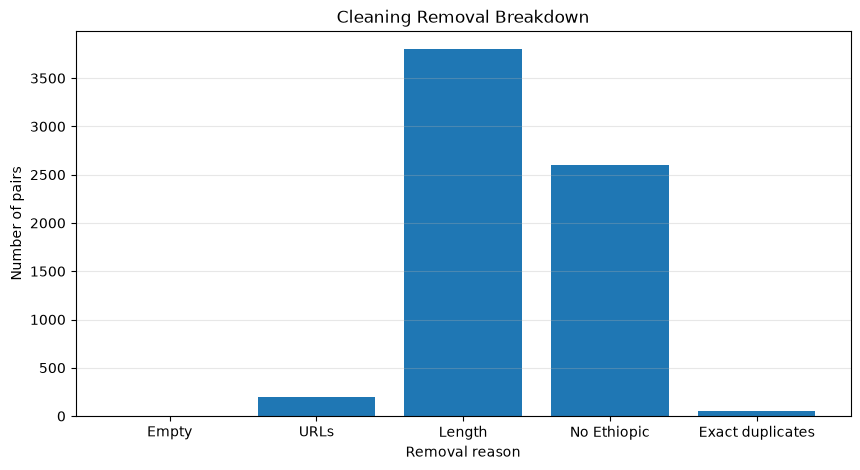

In [16]:
removal_labels = [
    "Empty",
    "URLs",
    "Length",
    "No Ethiopic",
    "Exact duplicates",
]

removal_values = [
    cleaning_report["removed_empty"],
    cleaning_report["removed_urls"],
    cleaning_report["removed_length"],
    cleaning_report["removed_script"],
    cleaning_report["removed_dups"],
]

plt.figure(figsize=(10, 5))

plt.bar(removal_labels, removal_values)

plt.title("Cleaning Removal Breakdown")
plt.xlabel("Removal reason")
plt.ylabel("Number of pairs")
plt.grid(axis="y", alpha=0.3)

plt.show()

## 5. Sentence-Length Comparison

The same whitespace-based word-count method is used for both datasets.

In [17]:
def add_length_columns(dataframe):
    result = dataframe[["eng", "amh"]].copy()

    result["eng_word_count"] = (
        result["eng"]
        .fillna("")
        .astype(str)
        .str.split()
        .str.len()
    )

    result["amh_word_count"] = (
        result["amh"]
        .fillna("")
        .astype(str)
        .str.split()
        .str.len()
    )

    return result


raw_lengths = add_length_columns(raw_df)
clean_lengths = add_length_columns(clean_df)

print("Length columns created.")

Length columns created.


### Before-and-after length statistics

In [18]:
length_comparison = pd.DataFrame({
    "Raw English": raw_lengths["eng_word_count"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ),
    "Cleaned English": clean_lengths["eng_word_count"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ),
    "Raw Amharic": raw_lengths["amh_word_count"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ),
    "Cleaned Amharic": clean_lengths["amh_word_count"].describe(
        percentiles=[0.50, 0.75, 0.90, 0.95, 0.99]
    ),
})

display(length_comparison.round(2))

,Raw English,Cleaned English,Raw Amharic,Cleaned Amharic
count,669145.00,662491.00,669145.00,662491.00
mean,21.41,21.53,14.59,14.67
std,12.19,11.99,8.62,8.45
min,1.00,2.00,1.00,2.00
50%,19.00,19.00,13.00,13.00
75%,28.00,28.00,18.00,18.00
90%,37.00,37.00,25.00,25.00
95%,44.00,44.00,30.00,30.00
99%,61.00,60.00,44.00,44.00
max,120.00,100.00,118.00,100.00


### Compare English distributions

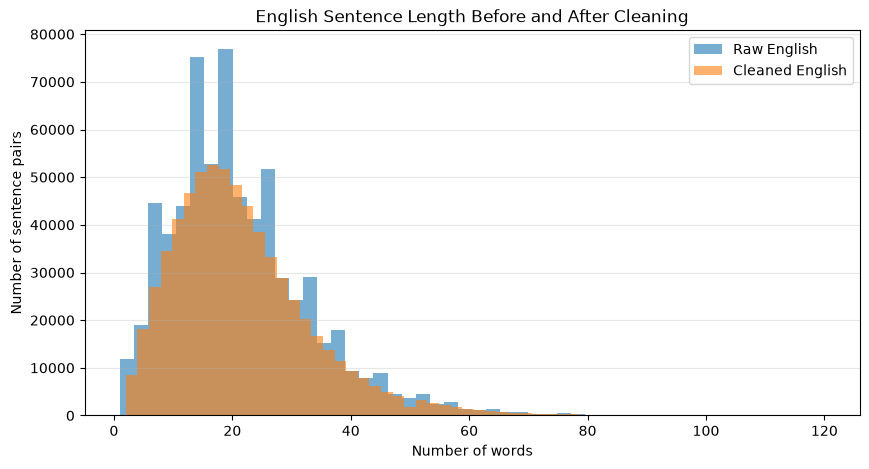

In [19]:
plt.figure(figsize=(10, 5))

plt.hist(
    raw_lengths["eng_word_count"],
    bins=50,
    alpha=0.6,
    label="Raw English"
)

plt.hist(
    clean_lengths["eng_word_count"],
    bins=50,
    alpha=0.6,
    label="Cleaned English"
)

plt.title("English Sentence Length Before and After Cleaning")
plt.xlabel("Number of words")
plt.ylabel("Number of sentence pairs")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

### Compare Amharic distributions

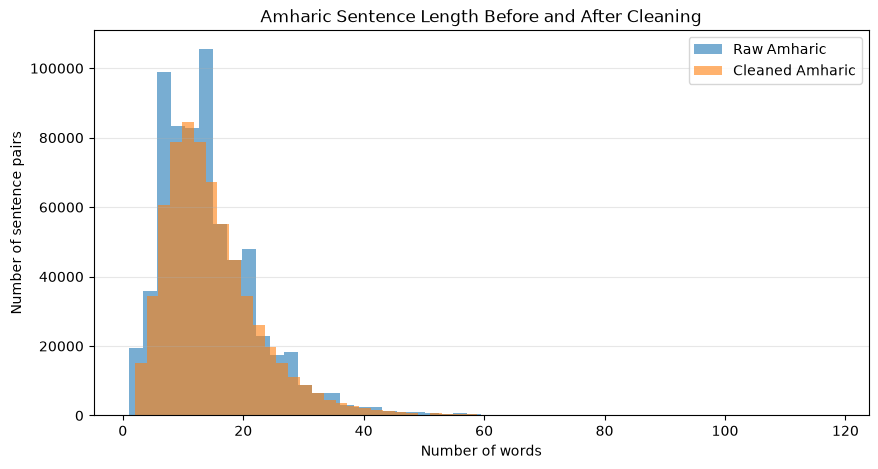

In [20]:
plt.figure(figsize=(10, 5))

plt.hist(
    raw_lengths["amh_word_count"],
    bins=50,
    alpha=0.6,
    label="Raw Amharic"
)

plt.hist(
    clean_lengths["amh_word_count"],
    bins=50,
    alpha=0.6,
    label="Cleaned Amharic"
)

plt.title("Amharic Sentence Length Before and After Cleaning")
plt.xlabel("Number of words")
plt.ylabel("Number of sentence pairs")
plt.legend()
plt.grid(axis="y", alpha=0.3)

plt.show()

### Verify final length bounds

In [21]:
MIN_LENGTH = 2
MAX_LENGTH = 100

clean_english_outside_bounds = (
    (clean_lengths["eng_word_count"] < MIN_LENGTH) |
    (clean_lengths["eng_word_count"] > MAX_LENGTH)
)

clean_amharic_outside_bounds = (
    (clean_lengths["amh_word_count"] < MIN_LENGTH) |
    (clean_lengths["amh_word_count"] > MAX_LENGTH)
)

print(
    "Cleaned English sentences outside bounds:",
    clean_english_outside_bounds.sum()
)

print(
    "Cleaned Amharic sentences outside bounds:",
    clean_amharic_outside_bounds.sum()
)

assert clean_english_outside_bounds.sum() == 0
assert clean_amharic_outside_bounds.sum() == 0

print("Length-bound verification passed.")

Cleaned English sentences outside bounds: 0
Cleaned Amharic sentences outside bounds: 0
Length-bound verification passed.


## 6. URL Verification

The cleaning pipeline removes any pair containing a URL in either the English or Amharic sentence.

In [22]:
URL_RE = re.compile(
    r"(?:https?://|www\.)\S+",
    flags=re.IGNORECASE,
)

clean_url_in_english = clean_df["eng"].fillna("").astype(str).apply(
    lambda text: bool(URL_RE.search(text))
)

clean_url_in_amharic = clean_df["amh"].fillna("").astype(str).apply(
    lambda text: bool(URL_RE.search(text))
)

clean_url_mask = clean_url_in_english | clean_url_in_amharic

url_verification = pd.DataFrame({
    "Count": [
        clean_url_in_english.sum(),
        clean_url_in_amharic.sum(),
        clean_url_mask.sum(),
    ],
}, index=[
    "URLs in English",
    "URLs in Amharic",
    "URL-containing pairs",
])

display(url_verification)

assert clean_url_mask.sum() == 0

print("URL-removal verification passed.")

,Count
URLs in English,0
URLs in Amharic,0
URL-containing pairs,0


URL-removal verification passed.


## 7. Ethiopic-Script Verification

The cleaning pipeline requires at least one Ethiopic character in every Amharic target sentence.

In [23]:
ETHIOPIC_RE = re.compile(r"[\u1200-\u137F]")

clean_has_ethiopic = clean_df["amh"].fillna("").astype(str).apply(
    lambda text: bool(ETHIOPIC_RE.search(text))
)

ethiopic_verification = pd.DataFrame({
    "Count": [
        clean_has_ethiopic.sum(),
        (~clean_has_ethiopic).sum(),
    ],
}, index=[
    "Targets containing Ethiopic characters",
    "Targets without Ethiopic characters",
])

display(ethiopic_verification)

assert (~clean_has_ethiopic).sum() == 0

print("Ethiopic-script verification passed.")

,Count
Targets containing Ethiopic characters,662491
Targets without Ethiopic characters,0


Ethiopic-script verification passed.


## 8. Missing and Empty-Value Verification

In [24]:
clean_eng_text = clean_df["eng"].fillna("").astype(str)
clean_amh_text = clean_df["amh"].fillna("").astype(str)

missing_empty_verification = pd.DataFrame({
    "Missing values": [
        clean_df["eng"].isna().sum(),
        clean_df["amh"].isna().sum(),
    ],
    "Empty or whitespace-only values": [
        clean_eng_text.str.strip().eq("").sum(),
        clean_amh_text.str.strip().eq("").sum(),
    ],
}, index=["English", "Amharic"])

display(missing_empty_verification)

assert clean_df["eng"].isna().sum() == 0
assert clean_df["amh"].isna().sum() == 0
assert clean_eng_text.str.strip().eq("").sum() == 0
assert clean_amh_text.str.strip().eq("").sum() == 0

print("Missing-value and empty-string verification passed.")

,Missing values,Empty or whitespace-only values
English,0,0
Amharic,0,0


Missing-value and empty-string verification passed.


## 9. Exact-Duplicate Verification

In [25]:
exact_duplicate_count_clean = clean_df.duplicated(
    subset=["eng", "amh"]
).sum()

print(f"Exact duplicate pairs in cleaned dataset: {exact_duplicate_count_clean:,}")

assert exact_duplicate_count_clean == 0

print("Exact-duplicate verification passed.")

Exact duplicate pairs in cleaned dataset: 0
Exact-duplicate verification passed.


## 10. Markup Verification

The cleaning pipeline removes recognized HTML-like tags such as `<p>`, `<br>`, `<div>`, `<span>`, and similar tags.

This check reports remaining angle-bracket patterns for manual inspection. It is not used as an automatic failure condition because angle brackets may occur as legitimate punctuation or content.

In [26]:
HTML_TAG_RE = re.compile(r"<[^>]+>")

remaining_markup_in_english = clean_df["eng"].fillna("").astype(str).apply(
    lambda text: bool(HTML_TAG_RE.search(text))
)

remaining_markup_in_amharic = clean_df["amh"].fillna("").astype(str).apply(
    lambda text: bool(HTML_TAG_RE.search(text))
)

remaining_markup_mask = (
    remaining_markup_in_english |
    remaining_markup_in_amharic
)

print(
    "Cleaned pairs containing remaining angle-bracket patterns:",
    remaining_markup_mask.sum()
)

if remaining_markup_mask.sum() > 0:
    display(
        clean_df.loc[
            remaining_markup_mask,
            ["eng", "amh"]
        ].head(20)
    )
else:
    print("No remaining angle-bracket patterns were found.")

Cleaned pairs containing remaining angle-bracket patterns: 115


,eng,amh
18175,"< < For the Chief Musician . For a stringed instrument . By David . > > Hear my cry , God . Listen to my prayer .",አምላክ ሆይ ፥ ልመናዬን ስማ ፥ ጸሎቴንም አድምጥ ።
21130,"< < For the Chief Musician . To the tune of "" Do Not Destroy . "" A poem by David . > > Do you indeed speak righteousness , silent ones ? Do you judge blamelessly , you sons of men ?",በእውነት ጽድቅን ብትናገሩስ ፥ የሰው ልጆች ሆይ ፥ በቅን ትፈርዳላችሁ ፤
22102,< < A Psalm by David . > > Yahweh is my shepherd : I shall lack nothing .,እግዚአብሔር እረኛዬ ነው ፥ የሚያሳጣኝም የለም ።
29410,"< < A Psalm by David . > > Ascribe to Yahweh , you sons of the mighty , ascribe to Yahweh glory and strength .",የአምላክ ልጆች ሆይ ፥ ለእግዚአብሔር አምጡ ። ክብርንና ምስጋናን ለእግዚአብሔር አምጡ ።
30429,"< < A Psalm . > > Sing to Yahweh a new song , for he has done marvelous things ! His right hand , and his holy arm , have worked salvation for him .",ለእግዚአብሔር አዲስ ምስጋናን አመስግኑ ፥ እግዚአብሔር ተኣምራትን አድርጎአልና ፤ ቀኙ የተቀደሰም ክንዱ ለእርሱ ማዳን አደረገ ።
41598,"< < A Psalm by David . > > Yahweh , who shall dwell in your sanctuary ? Who shall live on your holy hill ?",አቤቱ ፥ በድንኳንህ ውስጥ ማን ያድራል ? በተቀደሰውም ተራራህ ማን ይኖራል ?
48162,"< < A contemplation by Asaph . > > God , why have you rejected us forever ? Why does your anger smolder against the sheep of your pasture ?",አቤቱ ፥ ስለ ምን ለዘወትር ጣልኸኝ ? በማሰማርያህ በጎች ላይስ ቍጣህን ስለ ምን ተቈጣህ ?
61217,"< < For the Chief Musician . A Psalm by the sons of Korah . > > Oh clap your hands , all you nations . Shout to God with the voice of triumph !",አሕዛብ ሁላችሁ ፥ እጆቻችሁን አጨብጭቡ ፥ በደስታ ቃልም ለእግዚአብሔር እልል በሉ ።
61282,"< < For the Chief Musician . To the tune of "" Lilies . "" By David . > > Save me , God , for the waters have come up to my neck !",አቤቱ ፥ ውኃ እስከ ነፍሴ ደርሶብኛልና አድነኝ ።
73018,"--description < description \ _ BAR _ file > , -D < description \ _ BAR _ file > Provide a descriptive name for the command to be used in the default message , making it nicer . You can also provi...","--መግለጫ < description \ _ BAR _ file > , -መ < description \ _ BAR _ file > ማቅረብ መግለጫ ስም ለትእዛዙ እንዲጠቀምበት በነበረው መልእክት , ጥሩ እንዲያደርገው . እንዲሁም ማቅረብ ይችላሉ ሁሉንም መንገድ ለዴስክቶፕ ፋይል . ቁልፍ ስምን ይጠቀማል በዚህ ሁኔታ"


## 11. Inspect Cleaned Translation Pairs

In [27]:
clean_sample = clean_df[["eng", "amh"]].sample(
    n=min(10, len(clean_df)),
    random_state=42
).reset_index(drop=True)

display(clean_sample)

,eng,amh
0,"We must be on guard and never drift downhill , back into the world , perhaps to be choked spiritually .",ከፍ ካለው የንጹሕ አምልኮ ስፍራ ተንሸራትተን ወደ ታች በመውረድ ዓለም ውስጥ ገብተን በመንፈሳዊ ታፍነን እንዳንሞት ልንጠነቀቅ ይገባል ።
1,"Mom had to work continually to make ends meet , leaving my sister and me with neighbors after school .",በዚህ ምክንያት በአንድ ወላጅ ብቻ የምንተዳደር ቤተሰቦች ሆንን ።
2,"The world may view angry behavior as normal , but it dishonors our Creator .",የሚያሳዝነው እንዲህ ያለው ምግባር አብዛኛውን ጊዜ ወደ ጠብ ይመራል ።
3,Repentant King Manasseh may have taught Josiah about God 's mercy .,ንጉሥ ምናሴ ንስሐ ከገባ በኋላ ኢዮስያስን ስለ አምላክ ምሕረት አስተምሮት ሊሆን ይችላል ።
4,( b ) Give examples to show the damage that the tongue can do .,( ለ ) አንደበት ጉዳት ሊያስከትል እንደሚችል የሚያሳዩ ምሳሌዎችን ጥቀስ ።
5,"For example , he made generous contributions toward the construction of Jehovah 's temple .",ለምሳሌ ያህል ፣ የይሖዋን ቤተ መቅደስ ግንባታ ለመደገፍ ከፍተኛ መዋጮ አድርጓል ።
6,Jesus said that many are on a road leading to destruction .,ኢየሱስ ብዙዎች ወደ ጥፋት በሚመራ መንገድ ላይ እየተጓዙ እንደሆነ ተናግሯል ።
7,I had two dogs - one named Vulkan and the other Palma . Palma was a faithful companion for many years .,ሁለት ውሻዎች የነበሩኝ ሲሆን አንደኛው ቩልካን ሌላዋ ደግሞ ፓልማ ይባሉ ነበር ።
8,"But God made him extraordinarily strong . ""","ሆኖም አምላክ ልዩ የሆነ ብርታት ሰጥቶታል ። """
9,Do those who do evil imagine that they will escape Us ? How ill they judge !,ይልቁንም እነዚያ መጥፎዎችን ሥራዎች የሚሠሩት ሊያመልጡን ይጠረጥራሉን ያ የሚፈርዱት ( ፍርድ ) ከፋ ፡ ፡


## 12. Verify the Parallel Text Files

The cleaning script also writes:

- `train_clean.en`
- `train_clean.am`

Each line should correspond to one row in the cleaned Parquet file.

### Verify .en and .am files

In [28]:
if not CLEAN_EN_FILE.exists():
    raise FileNotFoundError(f"English text file not found: {CLEAN_EN_FILE}")

if not CLEAN_AM_FILE.exists():
    raise FileNotFoundError(f"Amharic text file not found: {CLEAN_AM_FILE}")

clean_en_lines = CLEAN_EN_FILE.read_text(encoding="utf-8").splitlines()
clean_am_lines = CLEAN_AM_FILE.read_text(encoding="utf-8").splitlines()

print(f"Cleaned Parquet rows : {len(clean_df):,}")
print(f"English text lines   : {len(clean_en_lines):,}")
print(f"Amharic text lines   : {len(clean_am_lines):,}")

assert len(clean_en_lines) == len(clean_df)
assert len(clean_am_lines) == len(clean_df)

print("Parallel text-file line counts match the cleaned Parquet dataset.")

Cleaned Parquet rows : 662,491
English text lines   : 662,491
Amharic text lines   : 662,491
Parallel text-file line counts match the cleaned Parquet dataset.


### Verify text-file content

In [29]:
parquet_en = clean_df["eng"].astype(str).tolist()
parquet_am = clean_df["amh"].astype(str).tolist()

assert clean_en_lines == parquet_en
assert clean_am_lines == parquet_am

print("The `.en` and `.am` files exactly match the cleaned Parquet content.")

The `.en` and `.am` files exactly match the cleaned Parquet content.


## 13. Final Preprocessing Summary

In [30]:
final_summary = {
    "Raw sentence pairs": len(raw_df),
    "Cleaned sentence pairs": len(clean_df),
    "Removed sentence pairs": len(raw_df) - len(clean_df),
    "Retention percentage": round(len(clean_df) / len(raw_df) * 100, 2),
    "Removed URL pairs": cleaning_report["removed_urls"],
    "Removed length-invalid pairs": cleaning_report["removed_length"],
    "Removed non-Ethiopic targets": cleaning_report["removed_script"],
    "Removed exact duplicates": cleaning_report["removed_dups"],
    "Remaining missing values": int(clean_df[["eng", "amh"]].isna().sum().sum()),
    "Remaining empty values": int(
        clean_eng_text.str.strip().eq("").sum()
        + clean_amh_text.str.strip().eq("").sum()
    ),
    "Remaining URL pairs": int(clean_url_mask.sum()),
    "Remaining exact duplicates": int(exact_duplicate_count_clean),
    "English sentences outside length bounds": int(clean_english_outside_bounds.sum()),
    "Amharic sentences outside length bounds": int(clean_amharic_outside_bounds.sum()),
    "Targets without Ethiopic characters": int((~clean_has_ethiopic).sum()),
}

final_summary_df = pd.DataFrame(
    list(final_summary.items()),
    columns=["Metric", "Value"]
)

display(final_summary_df)

,Metric,Value
0,Raw sentence pairs,669145.00
1,Cleaned sentence pairs,662491.00
2,Removed sentence pairs,6654.00
3,Retention percentage,99.01
4,Removed URL pairs,202.00
5,Removed length-invalid pairs,3798.00
6,Removed non-Ethiopic targets,2603.00
7,Removed exact duplicates,51.00
8,Remaining missing values,0.00
9,Remaining empty values,0.00


## 14. Final Preprocessing Decision

The cleaned corpus is considered ready for the next stage when:

- The saved cleaned row count matches the centralized cleaning report.
- No missing or empty source-target values remain.
- No URL-containing pairs remain.
- No exact duplicate translation pairs remain.
- All sentence lengths are between 2 and 100 words.
- Every Amharic target contains at least one Ethiopic character.
- The `.en` and `.am` files match the cleaned Parquet dataset exactly.

The next stage is:

1. Train/validation/test splitting
2. Tokenization
3. Vocabulary construction
4. Dataset preparation for the baseline Seq2Seq model